#### 環境初始化

In [1]:
%pip install plotly
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install numpy
%pip install scikit-learn
%pip install keplergl
%pip install kneed
%pip install "setuptools<70"
%pip install ipywidgets
!wget -O font.ttf https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached keplergl-0.3.7-py2.py3-none-any.whl
  Using

In [15]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import geopandas as gp
import numpy as np
from keplergl import KeplerGl
from kneed import KneeLocator
import plotly.express as px
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
# @title
def get_font_prop():
  font_path = 'font.ttf'
  font_prop = fm.FontProperties(fname=font_path)
  plt.rcParams['font.family'] = font_prop.get_name()
  fm.fontManager.addfont(font_path)
  return font_prop

In [4]:
# @title
PM25BINS = [0, 15.4, 35.4, 54.4, 150.4, 250.4, 350.4]
PM25STATUS = ["良好", "普通", "對敏感族群不健康", "對所有族群不健康", "非常不健康", "危害"]
START_DATE = "2019-01-01"
EN_CH_MAP = {
    "Keelung": "基隆",
    "Zhongli": "中壢",
    "Songshan": "松山",
    "Tamsui": "淡水",
    "Shilin": "士林",
    "Guanyin": "觀音",
    "Xinzhuang": "新莊",
    "Yangming": "陽明",
    "Dali": "大里",
    "Shalu": "沙鹿",
    "Zhongming": "忠明",
    "Fengyuan": "豐原",
    "Nantou": "南投",
    "Puli": "埔里",
    "Mailiao": "麥寮",
    "Nanzih": "楠梓",
    "Xiaogang": "小港",
    "Linyuan": "林園",
    "Fengshan": "鳳山",
    "Hengchun": "恆春",
}
COUNTY_MAP = {
    '大里': '臺中市',
    '鳳山': '高雄市',
    '豐原': '臺中市',
    '觀音': '桃園市',
    '恆春': '屏東縣',
    '基隆': '基隆市',
    '林園': '高雄市',
    '麥寮': '雲林縣',
    '南投': '南投縣',
    '楠梓': '高雄市',
    '埔里': '南投縣',
    '沙鹿': '臺中市',
    '士林': '臺北市',
    '松山': '臺北市',
    '淡水': '新北市',
    '小港': '高雄市',
    '新莊': '新北市',
    '陽明': '臺北市',
    '中壢': '桃園市',
    '忠明': '臺中市'
}
TOWN_MAP = {
    '大里': '大里區',
    '鳳山': '鳳山區',
    '豐原': '豐原區',
    '觀音': '觀音區',
    '恆春': '恆春鎮',
    '基隆': '仁愛區',
    '林園': '林園區',
    '麥寮': '麥寮鄉',
    '南投': '魚池鄉',
    '楠梓': '楠梓區',
    '埔里': '埔里鎮',
    '沙鹿': '沙鹿區',
    '士林': '士林區',
    '松山': '松山區',
    '淡水': '淡水區',
    '小港': '小港區',
    '新莊': '新莊區',
    '陽明': '北投區',
    '中壢': '中壢區',
    '忠明': '西區'
}
KEPLERGL_CONFIG = {
    "version": "v1",
    "config": {
        "visState": {
            "filters": [
                {
                    "dataId": ["pm25"],
                    "id": "g6vfq4wfk",
                    "name": ["日期"],
                    "type": "timeRange",
                    "value": [1546300800000, 1553629244000],
                    "plotType": "histogram",
                    "animationWindow": "incremental",
                    "yAxis": None,
                    "view": "enlarged",
                    "speed": 0.1,
                    "enabled": True,
                }
            ],
            "layers": [
                {
                    "id": "5n5iku4",
                    "type": "geojson",
                    "config": {
                        "dataId": "pm25",
                        "label": "pm25",
                        "color": [77, 193, 156],
                        "highlightColor": [252, 242, 26, 255],
                        "columns": {"geojson": "geometry"},
                        "isVisible": True,
                        "visConfig": {
                            "opacity": 1,
                            "strokeOpacity": 0.8,
                            "thickness": 0.5,
                            "strokeColor": [255, 254, 230],
                            "colorRange": {
                                "name": "Custom Palette",
                                "type": "custom",
                                "category": "Custom",
                                "colors": ["#CA0034", "#FF9835", "#FFFB26", "#009865"],
                            },
                            "strokeColorRange": {
                                "name": "Global Warming",
                                "type": "sequential",
                                "category": "Uber",
                                "colors": [
                                    "#5A1846",
                                    "#900C3F",
                                    "#C70039",
                                    "#E3611C",
                                    "#F1920E",
                                    "#FFC300",
                                ],
                            },
                            "radius": 10,
                            "sizeRange": [0, 10],
                            "radiusRange": [0, 50],
                            "heightRange": [0, 500],
                            "elevationScale": 5,
                            "enableElevationZoomFactor": True,
                            "stroked": True,
                            "filled": True,
                            "enable3d": False,
                            "wireframe": False,
                        },
                        "hidden": False,
                        "textLabel": [
                            {
                                "field": None,
                                "color": [255, 255, 255],
                                "size": 18,
                                "offset": [0, 0],
                                "anchor": "start",
                                "alignment": "center",
                                "outlineWidth": 0,
                                "outlineColor": [255, 0, 0, 255],
                                "background": False,
                                "backgroundColor": [0, 0, 200, 255],
                            }
                        ],
                    },
                    "visualChannels": {
                        "colorField": {"name": "pm25 狀態", "type": "string"},
                        "colorScale": "ordinal",
                        "strokeColorField": None,
                        "strokeColorScale": "quantile",
                        "sizeField": None,
                        "sizeScale": "linear",
                        "heightField": None,
                        "heightScale": "linear",
                        "radiusField": None,
                        "radiusScale": "linear",
                    },
                }
            ],
            "effects": [],
            "interactionConfig": {
                "tooltip": {
                    "fieldsToShow": {
                        "pm25": [
                            {"name": "PM25", "format": None},
                            {"name": "pm25 狀態", "format": None},
                            {"name": "日期", "format": None},
                            {"name": "中文站名", "format": None},
                            {"name": "TOWNNAME", "format": None},
                            {"name": "COUNTYNAME", "format": None},
                        ]
                    },
                    "compareMode": False,
                    "compareType": "absolute",
                    "enabled": True,
                },
                "brush": {"size": 0.5, "enabled": False},
                "geocoder": {"enabled": False},
                "coordinate": {"enabled": False},
            },
            "layerBlending": "normal",
            "overlayBlending": "normal",
            "splitMaps": [],
            "animationConfig": {"currentTime": None, "speed": 1},
            "editor": {"features": [], "visible": True},
        },
        "mapState": {
            "bearing": -59.777777777777786,
            "dragRotate": True,
            "latitude": 23.533038442106175,
            "longitude": 121.5121977976374,
            "pitch": 51.85184982216937,
            "zoom": 6.951941083083048,
            "isSplit": False,
            "isViewportSynced": True,
            "isZoomLocked": False,
            "splitMapViewports": [],
        },
        "mapStyle": {
            "styleType": "dark-matter",
            "topLayerGroups": {},
            "visibleLayerGroups": {
                "label": True,
                "road": True,
                "border": False,
                "building": True,
                "water": True,
                "land": True,
                "3d building": False,
            },
            "threeDBuildingColor": [
                15.035172933000911,
                15.035172933000911,
                15.035172933000911,
            ],
            "backgroundColor": [0, 0, 0],
            "mapStyles": {},
        },
    },
}



#### 讀取資料並轉換為長格式

In [5]:
# @title
pm25 = pd.read_csv('./csv/PM25.csv')
pm25.rename(columns={'Unnamed: 0': '監測站'}, inplace=True)
pm25_long = pm25.melt(id_vars=['監測站'], var_name='天', value_name='PM25')
pm25_long['天'] = pd.to_numeric(pm25_long['天'])
pm25_long['日期'] = pd.to_datetime(START_DATE) + pd.to_timedelta(pm25_long['天'] - 1, unit='D')
pm25_long['日期'] = pm25_long['日期'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
pm25_long['中文站名'] = pm25_long['監測站'].map(EN_CH_MAP)
pm25_long['TOWNNAME'] = pm25_long['中文站名'].map(TOWN_MAP)
pm25_long['COUNTYNAME'] = pm25_long['中文站名'].map(COUNTY_MAP)
pm25_long['pm25 狀態'] = pd.cut(pm25_long['PM25'], bins=PM25BINS, labels=PM25STATUS, include_lowest=True)
pm25_long = pm25_long.drop(['天', '監測站'], axis=1)
print(pm25_long)
# pm25_long.to_csv("pm25.csv")
print("檢視是否有缺失值:", pm25_long.isnull().any().any())

           PM25                    日期 中文站名 TOWNNAME COUNTYNAME   pm25 狀態
0     27.458333  2019-01-01T00:00:00Z   基隆      仁愛區        基隆市        普通
1     34.666667  2019-01-01T00:00:00Z   中壢      中壢區        桃園市        普通
2     25.291667  2019-01-01T00:00:00Z   松山      松山區        臺北市        普通
3     28.333333  2019-01-01T00:00:00Z   淡水      淡水區        新北市        普通
4     28.333333  2019-01-01T00:00:00Z   士林      士林區        臺北市        普通
...         ...                   ...  ...      ...        ...       ...
7275  62.291667  2019-12-30T00:00:00Z   楠梓      楠梓區        高雄市  對所有族群不健康
7276  59.958333  2019-12-30T00:00:00Z   小港      小港區        高雄市  對所有族群不健康
7277  53.208333  2019-12-30T00:00:00Z   林園      林園區        高雄市  對敏感族群不健康
7278  56.000000  2019-12-30T00:00:00Z   鳳山      鳳山區        高雄市  對所有族群不健康
7279  26.270833  2019-12-30T00:00:00Z   恆春      恆春鎮        屏東縣        普通

[7280 rows x 6 columns]
檢視是否有缺失值: False


#### 加入地理資料並合併 PM2.5 資料

In [6]:
# @title
taiwan_shp = gp.read_file("./shp/TOWN_MOI_1140318.shp") # 全台灣村里界圖
taiwan_shp = taiwan_shp.to_crs(epsg=4326)
taiwan_shp.to_csv(path_or_buf="taiwan.csv")
pm25_taiwan = pd.merge(
    pm25_long,
    taiwan_shp[['COUNTYNAME', 'TOWNNAME','geometry']],
    left_on=['COUNTYNAME', 'TOWNNAME'],
    right_on=['COUNTYNAME', 'TOWNNAME'],
    how='left'
)
pm25_taiwan_gdf = gp.GeoDataFrame(pm25_taiwan, geometry='geometry')
pm25_taiwan_gdf['geometry'] = pm25_taiwan_gdf.geometry.simplify(0.0001)
print(pm25_taiwan_gdf)
print("檢視是否有缺失值:", pm25_taiwan_gdf.isnull().any().any())

           PM25                    日期 中文站名 TOWNNAME COUNTYNAME   pm25 狀態  \
0     27.458333  2019-01-01T00:00:00Z   基隆      仁愛區        基隆市        普通   
1     34.666667  2019-01-01T00:00:00Z   中壢      中壢區        桃園市        普通   
2     25.291667  2019-01-01T00:00:00Z   松山      松山區        臺北市        普通   
3     28.333333  2019-01-01T00:00:00Z   淡水      淡水區        新北市        普通   
4     28.333333  2019-01-01T00:00:00Z   士林      士林區        臺北市        普通   
...         ...                   ...  ...      ...        ...       ...   
7275  62.291667  2019-12-30T00:00:00Z   楠梓      楠梓區        高雄市  對所有族群不健康   
7276  59.958333  2019-12-30T00:00:00Z   小港      小港區        高雄市  對所有族群不健康   
7277  53.208333  2019-12-30T00:00:00Z   林園      林園區        高雄市  對敏感族群不健康   
7278  56.000000  2019-12-30T00:00:00Z   鳳山      鳳山區        高雄市  對所有族群不健康   
7279  26.270833  2019-12-30T00:00:00Z   恆春      恆春鎮        屏東縣        普通   

                                               geometry  
0     POLYGON ((121.74758 25.

#### 繪製 PM2.5 分佈地圖
- 使用中文站名取得真實縣市地區資訊對照 shp 檔中的村里名稱，將資料集納入地理資料。
- shp 檔參考[內政部全台灣村里界圖](https://data.gov.tw/dataset/7441)，包含村里名稱、經緯度等資訊。
- 依照 PM2.5 的平均值繪製台灣地圖，顏色深淺代表 PM2.5 的濃度。參考[環境部空氣品質指標](https://airtw.moenv.gov.tw/CHT/Information/Standard/AirQualityIndicator.aspx#tg2)

In [16]:
# @title
map_1 = KeplerGl()
map_1.config = KEPLERGL_CONFIG
map_1.add_data(data=pm25_taiwan_gdf, name='pm25')
map_1.save_to_html(file_name="pm25_map.html")
map_1

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to pm25_map.html!


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [{'dataId': ['pm25'], 'id': 'g6vfq4wfk', …

In [8]:
# @title
with open("config.py", 'w', encoding='utf-8') as f:
   f.write('KEPLERGL_CONFIG = {}'.format(map_1.config))

In [9]:
# @title
# 1. 準備矩陣：以 監測站 為列，Day 為特徵 (使用 Wide format 的 df)
X = pm25.set_index('監測站')

# 2. 處理缺失值 (本數據集無缺失值，但作為保險進行填充)
print("檢視是否有缺失值:", X.isnull().any().any())

# 3. 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 執行 PCA 並取得前三個主成分
pca_3d = PCA(n_components=3)
pca_3d_result = pca_3d.fit_transform(X_scaled)

# 5. 建立 DataFrame 方便繪圖
pca_3d_df = pd.DataFrame(
    data=pca_3d_result,
    columns=['PC1', 'PC2', 'PC3'],
)
pca_3d_df['監測站'] = X.index.map(EN_CH_MAP)

# 6. 繪製 3D 互動圖
fig = px.scatter_3d(
    pca_3d_df, x='PC1', y='PC2', z='PC3',
    color='監測站',
    text='監測站',
    title='PM2.5 PCA 3D 互動視圖',
    labels={'PC1': '第一主成分', 'PC2': '第二主成分', 'PC3': '第三主成分'},
    template='plotly_dark' # 使用深色主題，更有質感
)
# 7. 優化視覺效果
fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=False, showbackground=True, zeroline=True, showticklabels=True),
        yaxis=dict(showgrid=False, showbackground=True, zeroline=True, showticklabels=True),
        zaxis=dict(showgrid=False, showbackground=True, zeroline=True, showticklabels=True)
    )
)
fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
fig.write_html("pca_3d_visualization.html")
fig.show()

檢視是否有缺失值: False


### K-Means 聚類分析

#### 尋找最佳聚類數 (Optimal K) 的演算法摘要

##### 1. 手肘法 (Elbow Method)
*   **原理**：計算不同 $K$ 值下的 **SSE (Sum of Squared Errors)** 或稱為 **Inertia**。隨著 $K$ 增加，SSE 會自然下降。
*   **判斷基準**：尋找圖形中「下降斜率顯著趨緩」的轉折點，該點看起來像手肘的關節。這代表增加更多的群數對提升模型解釋力的邊際效益已經遞減。
*   **優點**：直觀且計算快速。

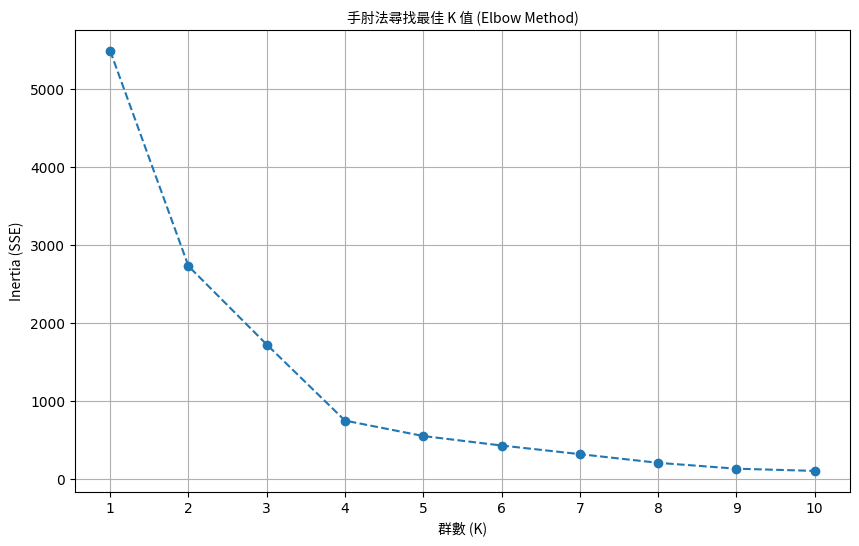

In [10]:
# @title
# 使用手肘法尋找最佳 K 值
inertia_list = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(pca_3d_result)
    inertia_list.append(kmeans_test.inertia_)

# 繪製手肘圖
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_list, marker='o', linestyle='--')
plt.title('手肘法尋找最佳 K 值 (Elbow Method)', fontproperties=get_font_prop())
plt.xlabel('群數 (K)', fontproperties=get_font_prop())
plt.ylabel('Inertia (SSE)', fontproperties=get_font_prop())
plt.xticks(k_range)
plt.grid(True)
plt.show()

#### 2. Kneedle 演算法 (Kneedle Algorithm)
*   **原理**：這是「手肘法」的數學進階版。它透過將曲線進行**正規化 (Normalization)** 並計算各點與線性趨勢線之間的距離。
*   **判斷基準**：自動找出曲線中「曲率最大」的點，即數學定義上的最佳轉折點。
*   **優點**：消除了人工觀察手肘圖的主觀誤差，適合自動化流程。

/tmp/ipykernel_821339/196952684.py:15: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  d = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


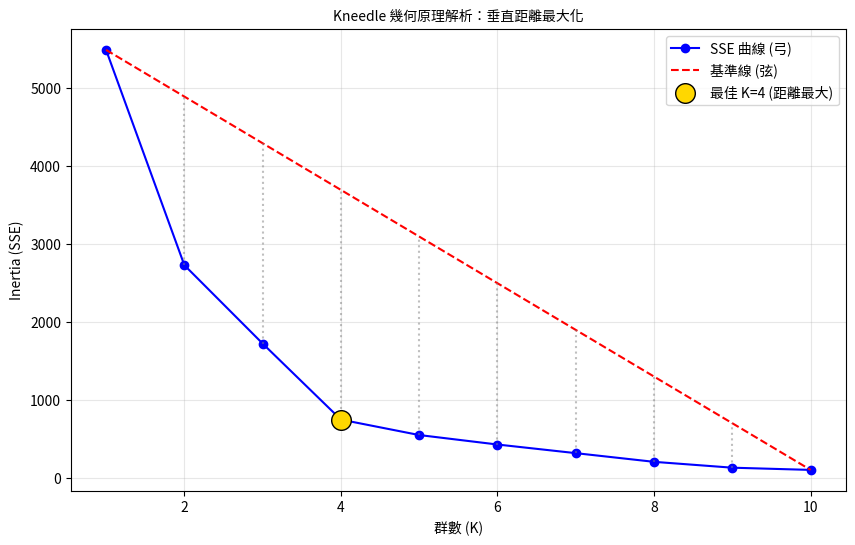

在幾何上，距離基準線最遠的點出現在 K = 4
根據 Kneedle 演算法，自動偵測到的最佳 K 值為: 4


<Figure size 1000x600 with 0 Axes>

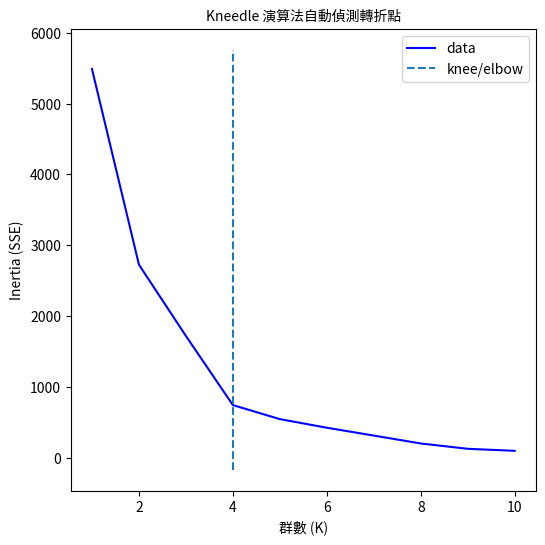

In [11]:
# @title
# 1. 準備資料點
x = np.array(list(k_range))
y = np.array(inertia_list)

# 2. 定義起點與終點的「基準線」(弦)
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])

# 3. 計算每個點到這條直線的垂直距離
# 公式：d = |(y2-y1)x0 - (x2-x1)y0 + x2y1 - y2x1| / sqrt((y2-y1)^2 + (x2-x1)^2)
distances = []
for i in range(len(x)):
    p0 = np.array([x[i], y[i]])
    d = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)
    distances.append(d)

# 4. 繪圖：弓箭視覺化
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'bo-', label='SSE 曲線 (弓)')
plt.plot([x[0], x[-1]], [y[0], y[-1]], 'r--', label='基準線 (弦)')

# 畫出垂直距離 (箭)
for i in range(len(x)):
    # 這裡簡化視覺化，畫垂直線段
    plt.vlines(x[i], ymin=y[i], ymax=np.interp(x[i], [x[0], x[-1]], [y[0], y[-1]]),
               colors='gray', linestyles='dotted', alpha=0.5)

# 標示出距離最大的點
max_idx = np.argmax(distances)
plt.scatter(x[max_idx], y[max_idx], color='gold', s=200, edgecolors='black', zorder=5, label=f'最佳 K={x[max_idx]} (距離最大)')

plt.title('Kneedle 幾何原理解析：垂直距離最大化', fontproperties=get_font_prop())
plt.xlabel('群數 (K)', fontproperties=get_font_prop())
plt.ylabel('Inertia (SSE)', fontproperties=get_font_prop())
plt.legend(prop=get_font_prop())
plt.grid(True, alpha=0.3)
plt.show()

print(f"在幾何上，距離基準線最遠的點出現在 K = {x[max_idx]}")

kn = KneeLocator(list(k_range), inertia_list, curve="convex", direction="decreasing")
print(f"根據 Kneedle 演算法，自動偵測到的最佳 K 值為: {kn.knee}")

# 繪製結果並標註 Knee 點
plt.figure(figsize=(10, 6))
kn.plot_knee()
plt.title('Kneedle 演算法自動偵測轉折點', fontproperties=get_font_prop())
plt.xlabel('群數 (K)', fontproperties=get_font_prop())
plt.ylabel('Inertia (SSE)', fontproperties=get_font_prop())
plt.show()

#### 3.輪廓係數法 (Silhouette Analysis)：
*   **原理**：這個方法透過計算每個樣本的輪廓係數，來評估聚類的緊密程度和分離程度。
*   **判斷基準**：輪廓係數的平均值越高，表示聚類效果越好。
*   **優點**：它提供了一個客觀的指標來評估不同 K 值下的聚類品質，幫助您找出資料結構的最佳 K 值。

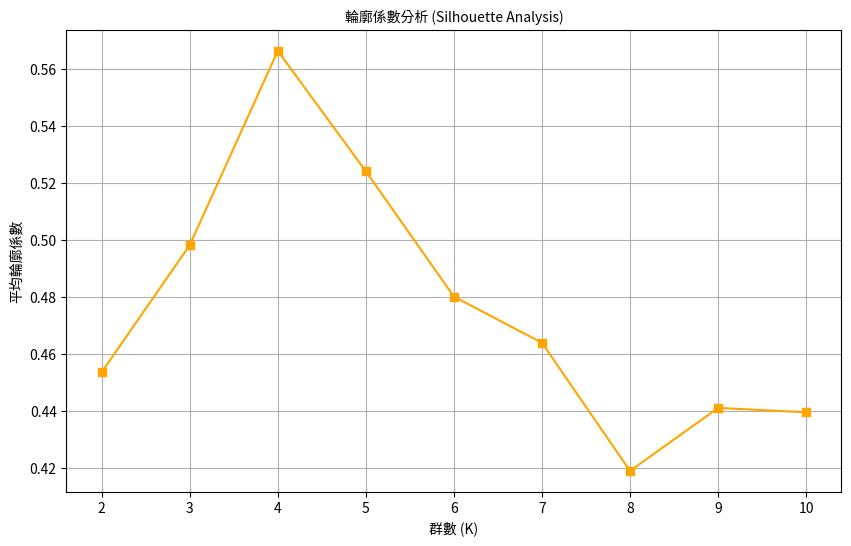

In [12]:
# @title
silhouette_avg_list = []
# 輪廓係數至少需要 2 個群組才能計算
for k in range(2, 11):
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_sil.fit_predict(pca_3d_result)

    # 計算平均輪廓係數
    silhouette_avg = silhouette_score(pca_3d_result, cluster_labels)
    silhouette_avg_list.append(silhouette_avg)

# 繪製輪廓係數圖
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_avg_list, marker='s', color='orange', linestyle='-')
plt.title('輪廓係數分析 (Silhouette Analysis)', fontproperties=get_font_prop())
plt.xlabel('群數 (K)', fontproperties=get_font_prop())
plt.ylabel('平均輪廓係數', fontproperties=get_font_prop())
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()



#### 利用 PCA 的結果進行聚類，找出污染特徵相似的站點。

In [ ]:
# @title
# 2. K-Means 聚類分析 (基於 PCA 的前三個主成分)
kmeans = KMeans(n_clusters=4, random_state=42)
pca_3d_df['Cluster'] = kmeans.fit_predict(pca_3d_result)

# 3. 視覺化聚類結果
fig_cluster = px.scatter_3d(
    pca_3d_df, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    text='監測站',
    title='PM2.5 站點聚類分析 (K-Means)',
    template='plotly_dark'
)
fig_cluster.show()
fig.write_html("pca_3d_visualization.html")

#### 各地區 PM2.5 濃度的季節性分析

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


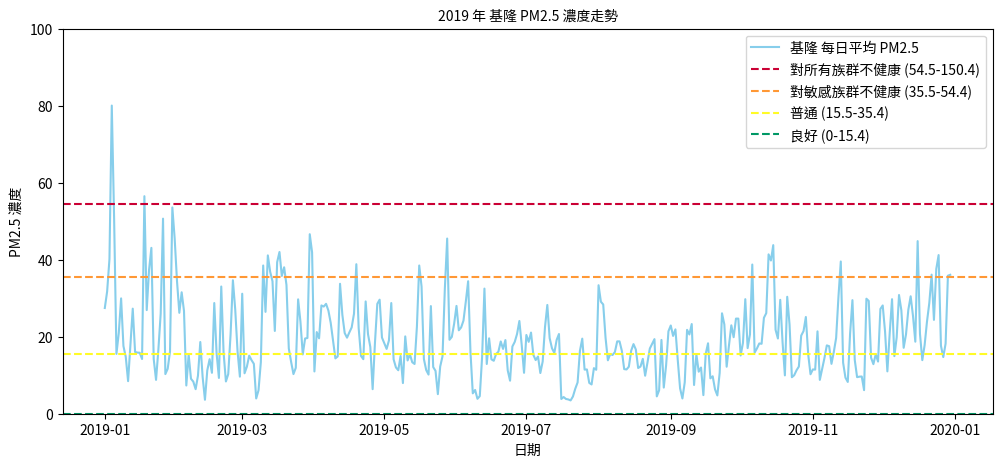

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


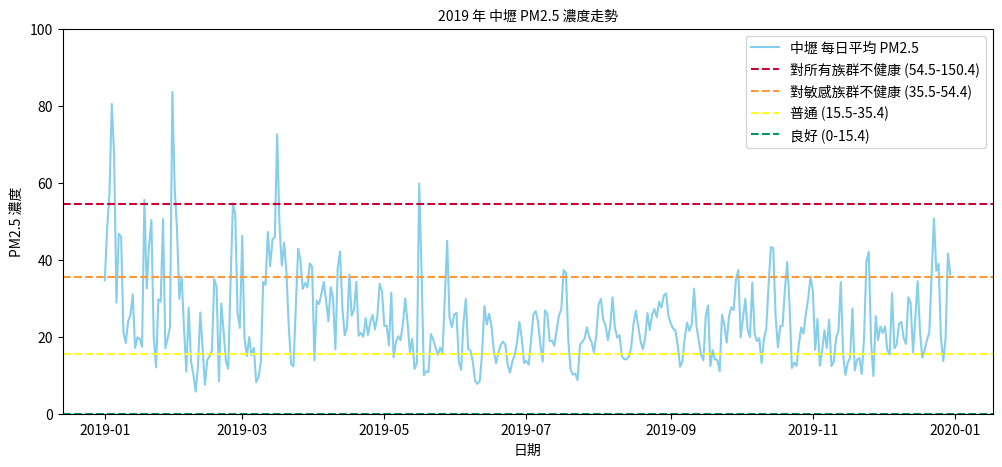

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


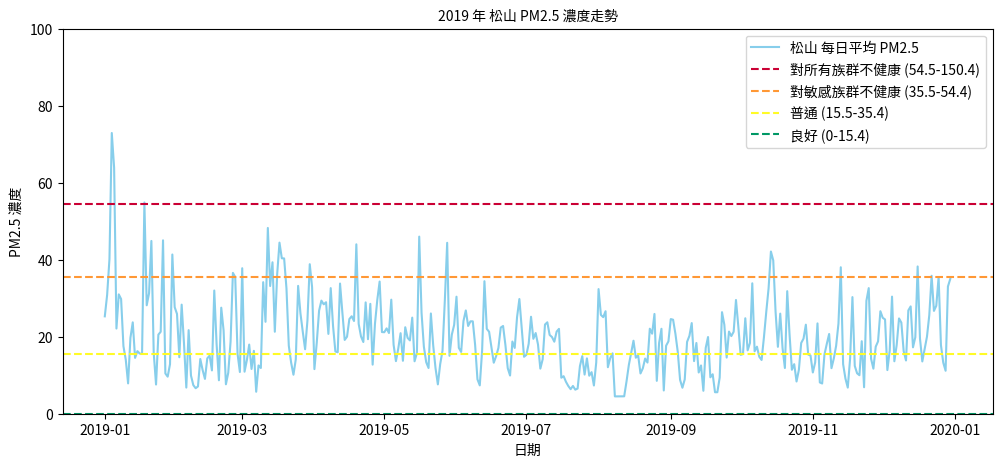

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


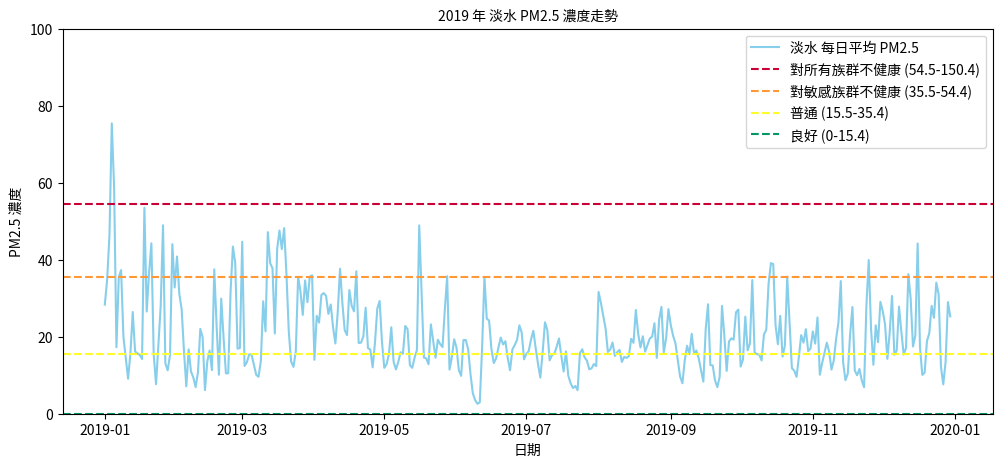

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


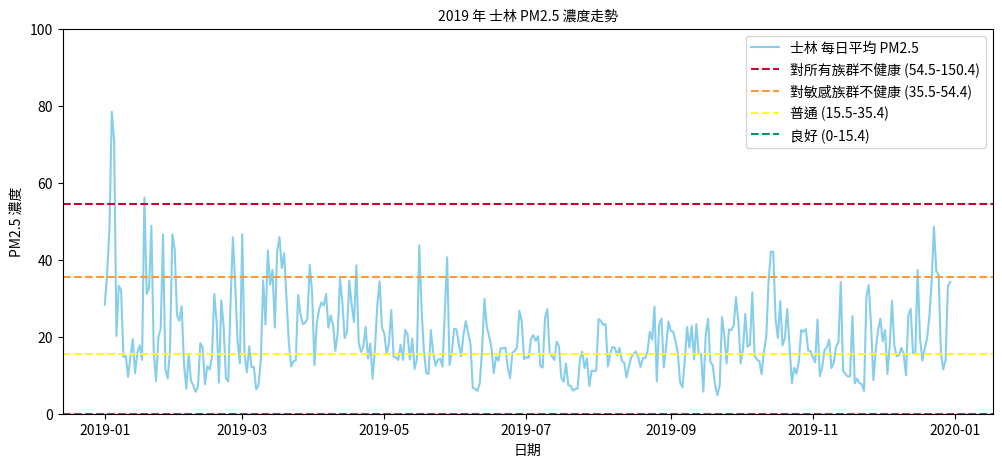

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


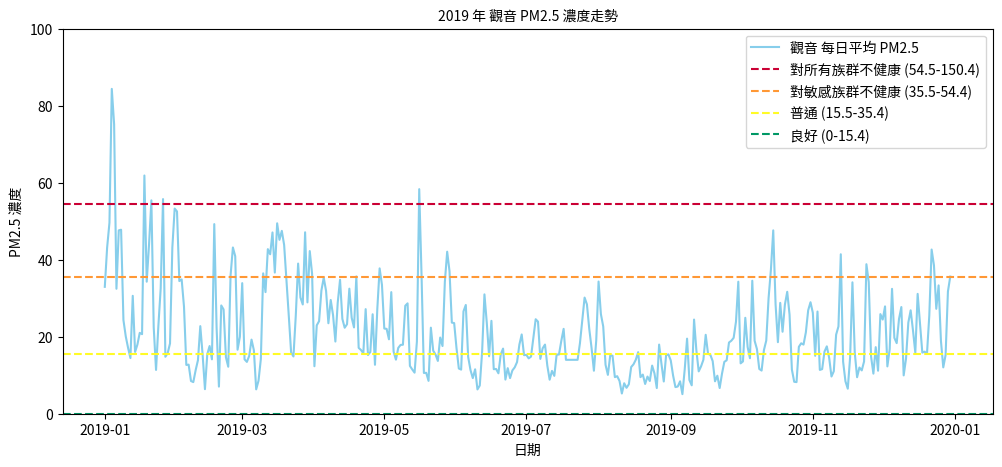

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


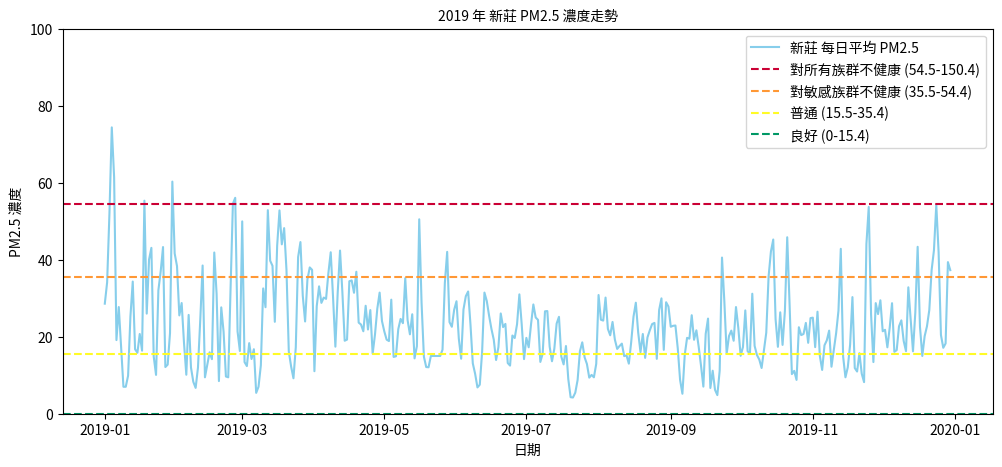

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


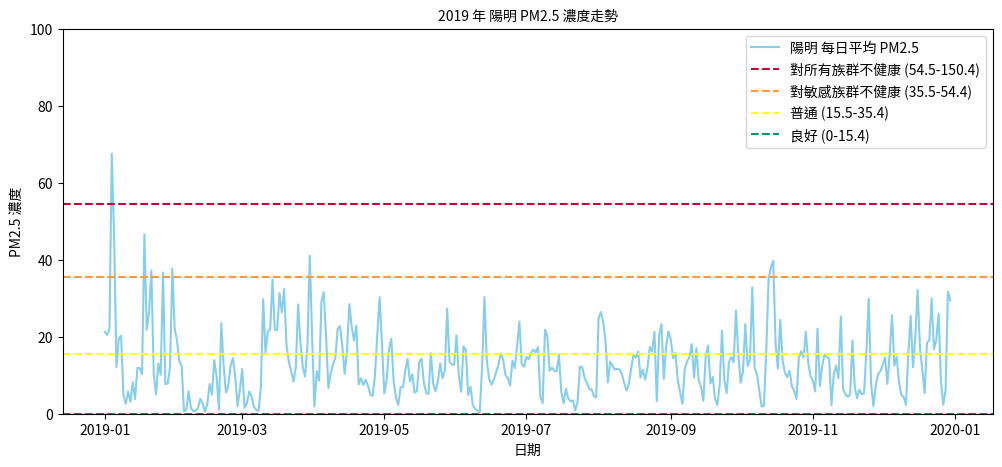

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


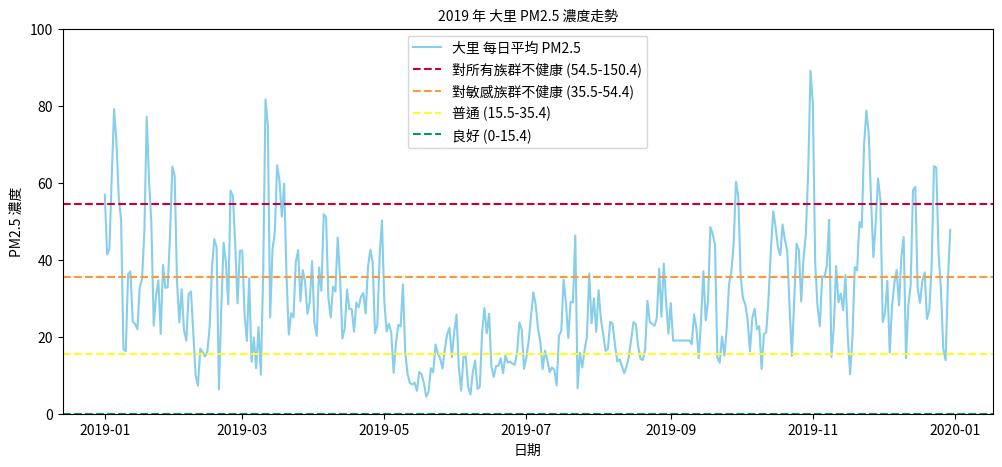

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


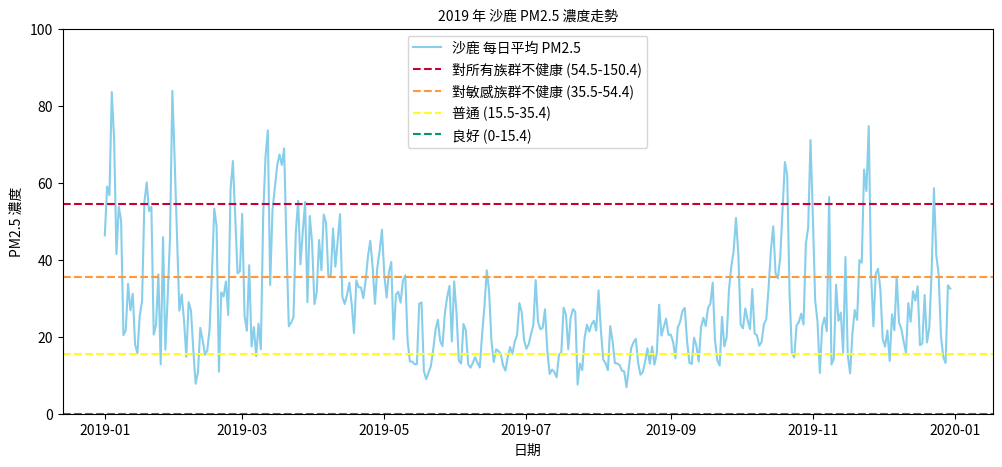

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


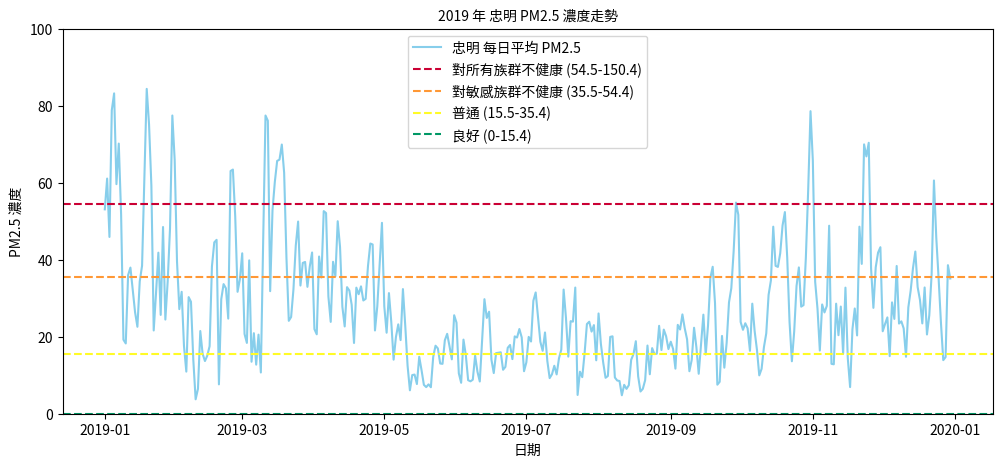

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


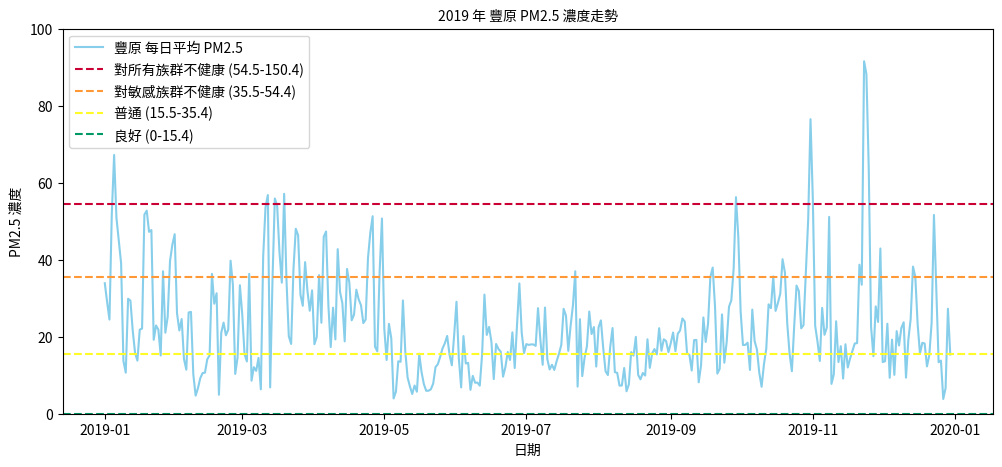

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


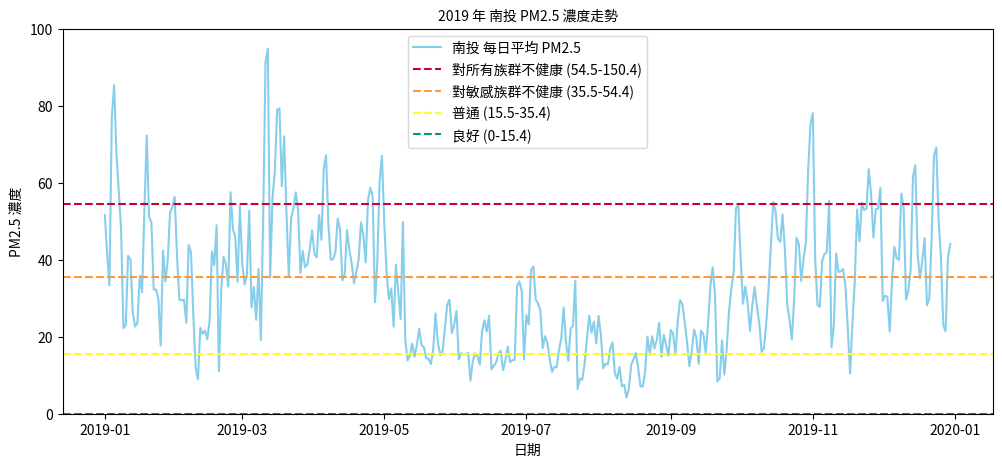

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


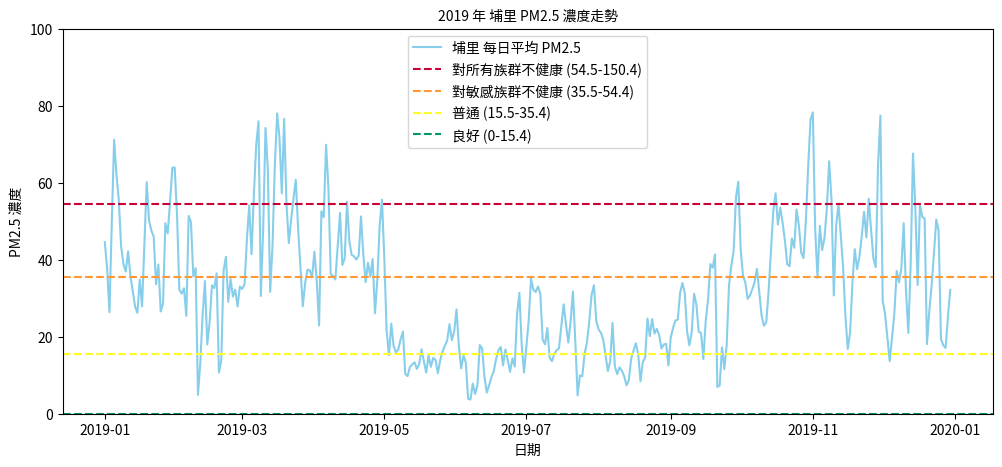

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


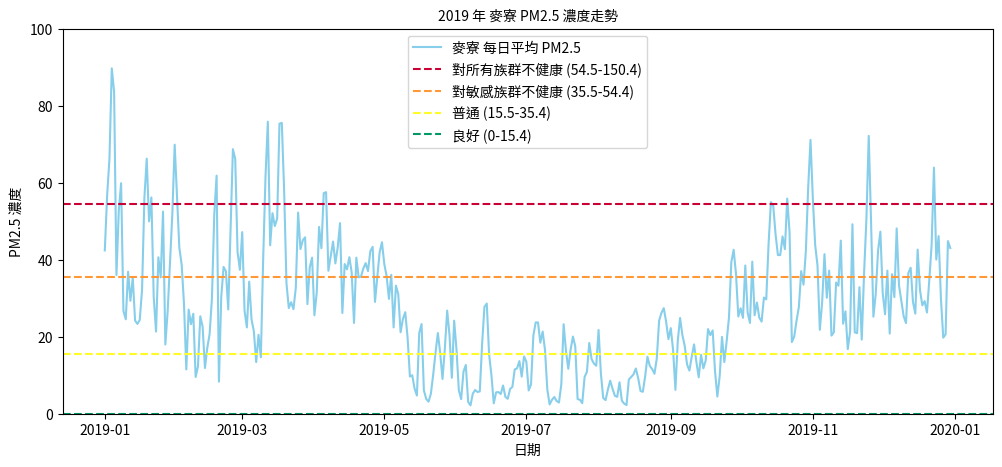

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


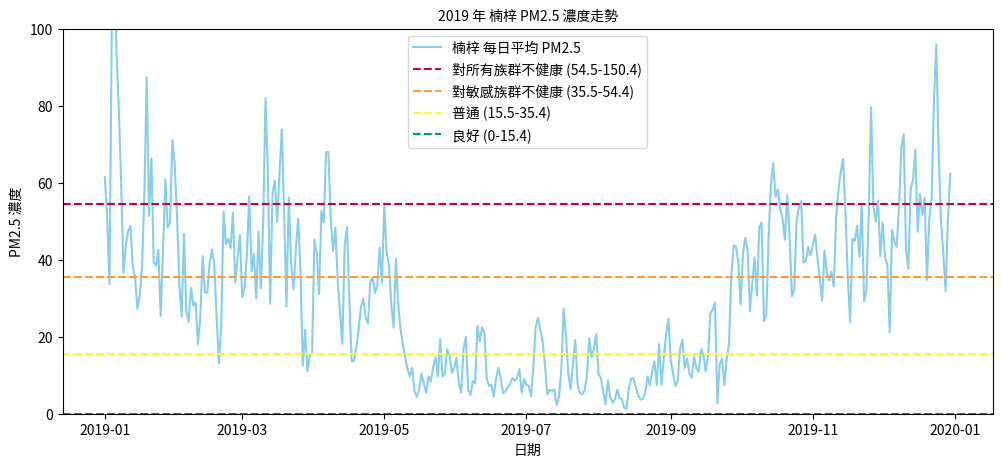

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


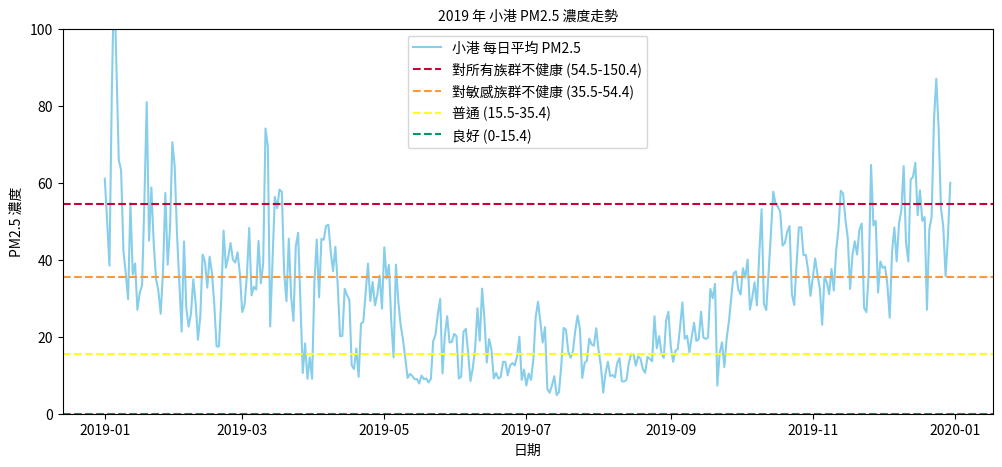

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


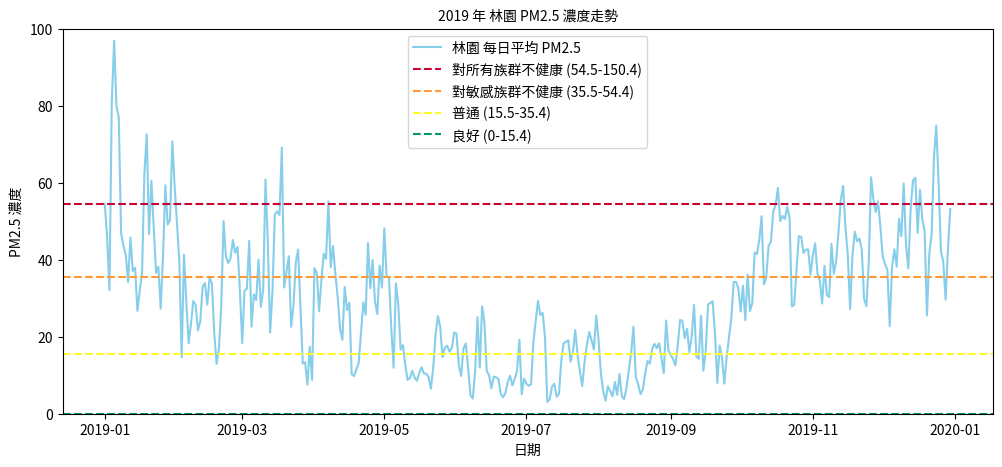

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


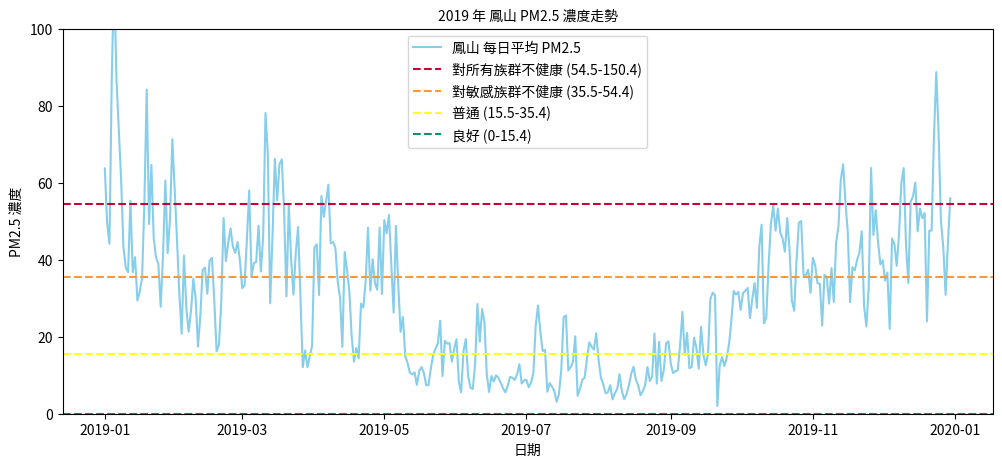

/tmp/ipykernel_821339/3000532523.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])


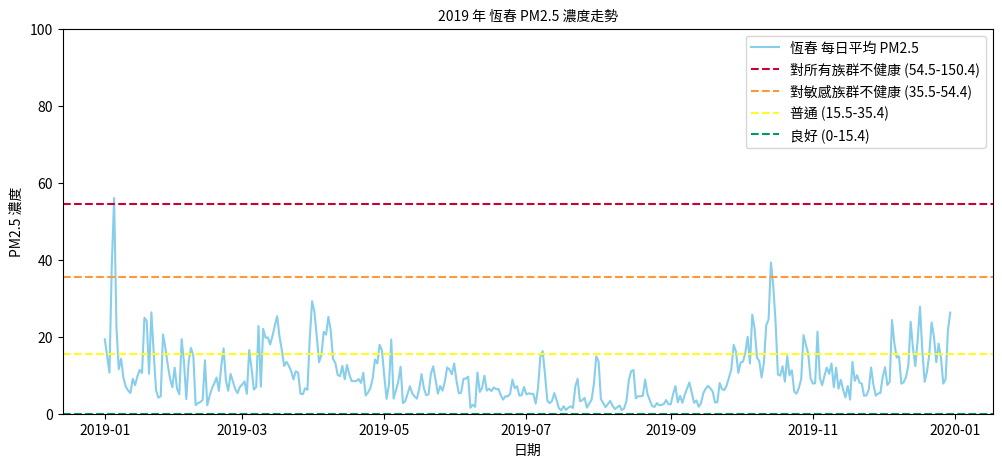

In [14]:
# @title
# 1. 季節性分析：計算全台日平均並轉換為月平均
for station in pm25_long['中文站名'].unique():
    sedation_pm25 = pm25_long[pm25_long['中文站名'] == station]
    # print(sedation_pm25)
    sedation_pm25['日期_dt'] = pd.to_datetime(sedation_pm25['日期'])
    sedation_pm25.set_index('日期_dt', inplace=True)
    # [0, 15.4, 35.4, 54.4, 150.4, 250.4, 350.4]
    # ["#CA0034", "#FF9835", "#FFFB26", "#009865"]
    plt.figure(figsize=(12, 5))
    plt.plot(sedation_pm25['PM25'], label=f'{station} 每日平均 PM2.5', color='skyblue')
    plt.axhline(y=54.5, color='#CA0034', linestyle='--', label='對所有族群不健康 (54.5-150.4)')
    plt.axhline(y=35.5, color='#FF9835', linestyle='--', label='對敏感族群不健康 (35.5-54.4)')
    plt.axhline(y=15.5, color='#FFFB26', linestyle='--', label='普通 (15.5-35.4)')
    plt.axhline(y=0, color='#009865', linestyle='--', label='良好 (0-15.4)')
    plt.title(f'2019 年 {station} PM2.5 濃度走勢', fontproperties=get_font_prop())
    plt.xlabel('日期', fontproperties=get_font_prop())
    plt.ylabel('PM2.5 濃度', fontproperties=get_font_prop())
    plt.legend(prop=get_font_prop())
    plt.ylim(0, 100)
    plt.show()


### 為什麼夏季 PM2.5 濃度較低？
根據數據觀察與討論，夏季（約 6-8 月）台灣 PM2.5 濃度顯著下降，主要歸因於以下三大因素：

1. **大氣擴散條件佳**：夏季盛行**西南季風**，氣流從海洋吹向陸地，空氣相對乾淨；且夏季垂直對流旺盛，污染物容易向上擴散。
2. **降雨洗滌作用**：夏季是台灣的雨季與颱風季，頻繁的降雨能有效地將空氣中的懸浮微粒「洗掉」，降低地面濃度。
3. **境外污染減少**：相較於秋冬季節東北季風可能夾帶亞洲大陸的境外污染物，夏季較少受到長程傳輸的影響。